# **1. Perkenalan Dataset**


## Dataset: Telco Customer Churn

**Sumber Dataset:**  
Dataset ini berasal dari [Kaggle - Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) yang awalnya disediakan oleh **IBM Sample Data Sets**. Dataset ini sering digunakan untuk studi kasus prediksi churn pelanggan di industri telekomunikasi.

**Business Problem:**  
Sebuah perusahaan telekomunikasi ingin memprediksi pelanggan mana yang berpotensi berhenti berlangganan (*churn*) agar dapat melakukan strategi retensi pelanggan secara tepat sasaran. Memprediksi churn lebih awal jauh lebih ekonomis dibandingkan biaya akuisisi pelanggan baru.

**Karakteristik Dataset:**
- **Jumlah baris:** 7.043 pelanggan
- **Jumlah kolom:** 21 fitur (termasuk target)
- **Target variable:** `Churn` (Yes / No) — binary classification
- **Tipe data:** campuran (numerik & kategorikal)

**Kategori Fitur:**

| Kategori | Fitur |
|---|---|
| **Demografis** | gender, SeniorCitizen, Partner, Dependents |
| **Layanan akun** | tenure, Contract, PaperlessBilling, PaymentMethod |
| **Layanan telepon** | PhoneService, MultipleLines |
| **Layanan internet** | InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies |
| **Tagihan** | MonthlyCharges, TotalCharges |
| **Identifier** | customerID (akan di-drop saat preprocessing) |
| **Target** | Churn |

**Tujuan Eksperimen:**  
Melakukan eksplorasi dan preprocessing data Telco Customer Churn untuk menghasilkan dataset siap latih yang akan digunakan pada tahap modelling machine learning.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn jupyter ipykernel

In [2]:
# Library dasar untuk manipulasi data
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Utilitas
import os
import warnings
warnings.filterwarnings('ignore')

# Style seaborn untuk plot yang lebih estetik
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Konfigurasi display pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Random seed untuk reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(" Semua library berhasil di-import")
print(f" Pandas version: {pd.__version__}")
print(f" NumPy version: {np.__version__}")
print(f" Scikit-learn version:", end=" ")
import sklearn
print(sklearn.__version__)
print(f" Random seed: {RANDOM_SEED}")

 Semua library berhasil di-import
 Pandas version: 2.3.3
 NumPy version: 2.4.4
 Scikit-learn version: 1.8.0
 Random seed: 42


# **3. Memuat Dataset**

Pada tahap ini, dataset `telco_churn_raw.csv` akan dimuat menggunakan pustaka pandas. File dataset berada di folder `telco_churn_raw/` yang merupakan satu level di atas folder notebook ini (`preprocessing/`).

**Langkah verifikasi awal yang dilakukan:**
1. Cek dimensi dataset (jumlah baris dan kolom)
2. Tampilkan 5 baris pertama untuk memahami struktur data
3. Cek tipe data setiap kolom (`.info()`)
4. Tampilkan statistik deskriptif fitur numerik (`.describe()`)
5. Cek tipe data secara terpisah untuk memetakan kolom numerik vs kategorikal

In [3]:
# Path relatif ke dataset (notebook di preprocessing/, dataset di telco_churn_raw/)
RAW_DATA_PATH = "../telco_churn_raw/telco_churn_raw.csv"

# Cek apakah file ada sebelum di-load
if not os.path.exists(RAW_DATA_PATH):
    raise FileNotFoundError(f"Dataset tidak ditemukan di: {RAW_DATA_PATH}")

# Load dataset
df = pd.read_csv(RAW_DATA_PATH)

print("Dataset berhasil dimuat")
print(f"Path: {RAW_DATA_PATH}")
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")

Dataset berhasil dimuat
Path: ../telco_churn_raw/telco_churn_raw.csv
Jumlah baris : 7,043
Jumlah kolom : 21


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Informasi tipe data dan non-null count:")
print("=" * 60)
df.info()

Informasi tipe data dan non-null count:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pa

In [6]:
print("Statistik deskriptif fitur numerik:")
print("=" * 60)
df.describe()

Statistik deskriptif fitur numerik:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Total kolom numerik   : {len(numerical_cols)}")
print(f"Total kolom kategorikal: {len(categorical_cols)}")
print()
print("Kolom Numerik:")
for col in numerical_cols:
    print(f"  - {col}")
print()
print("Kolom Kategorikal:")
for col in categorical_cols:
    print(f"  - {col}")

Total kolom numerik   : 3
Total kolom kategorikal: 18

Kolom Numerik:
  - SeniorCitizen
  - tenure
  - MonthlyCharges

Kolom Kategorikal:
  - customerID
  - gender
  - Partner
  - Dependents
  - PhoneService
  - MultipleLines
  - InternetService
  - OnlineSecurity
  - OnlineBackup
  - DeviceProtection
  - TechSupport
  - StreamingTV
  - StreamingMovies
  - Contract
  - PaperlessBilling
  - PaymentMethod
  - TotalCharges
  - Churn


# **4. Exploratory Data Analysis (EDA)**

EDA dibagi menjadi 4 sub-analisis:

1. **Cek kualitas data** — mendeteksi missing values, duplikat, dan anomali tipe data
2. **Analisis target variable** — memeriksa distribusi kelas Churn (apakah balanced atau imbalanced)
3. **Analisis fitur numerik** — distribusi, korelasi antar fitur, deteksi outlier
4. **Analisis fitur kategorikal** — distribusi setiap fitur dan hubungannya dengan target

---

### 4.1 Cek Kualitas Data

Tahap ini memastikan kualitas data dari sisi kelengkapan (missing values) dan keunikan (duplikat).

In [8]:
# Cek missing values per kolom
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

# Tampilkan hanya kolom yang ada missing-nya
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) == 0:
    print("Tidak ada missing values yang terdeteksi (NaN/null)")
else:
    print("Kolom dengan missing values:")
    print(missing_df)

print()
print(f"Total sel kosong di dataset: {df.isnull().sum().sum()}")

Tidak ada missing values yang terdeteksi (NaN/null)

Total sel kosong di dataset: 0


In [9]:
# Kemungkinan ada string kosong yang tidak terdeteksi sebagai NaN
print("Tipe data TotalCharges saat ini:", df['TotalCharges'].dtype)
print()

# Coba konversi ke numerik, baris yang gagal akan jadi NaN
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
hidden_missing = total_charges_numeric.isnull().sum()

print(f"Jumlah hidden missing di TotalCharges: {hidden_missing} baris")
print()

# Tampilkan baris yang bermasalah
if hidden_missing > 0:
    print("Sample baris dengan TotalCharges bermasalah:")
    problematic_rows = df[total_charges_numeric.isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]
    print(problematic_rows.head(10))

Tipe data TotalCharges saat ini: object

Jumlah hidden missing di TotalCharges: 11 baris

Sample baris dengan TotalCharges bermasalah:
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             


In [10]:
# Cek duplikat berdasarkan SELURUH kolom
total_duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat (semua kolom): {total_duplicates}")

# Cek duplikat berdasarkan customerID (seharusnya unik)
duplicate_ids = df['customerID'].duplicated().sum()
print(f"Jumlah customerID duplikat          : {duplicate_ids}")

# Cek apakah customerID benar-benar unik
unique_ids = df['customerID'].nunique()
print(f"Jumlah customerID unik              : {unique_ids:,}")
print(f"Total baris                         : {len(df):,}")

if unique_ids == len(df):
    print("\ncustomerID 100% unik - bisa di-drop saat preprocessing")

Jumlah baris duplikat (semua kolom): 0
Jumlah customerID duplikat          : 0
Jumlah customerID unik              : 7,043
Total baris                         : 7,043

customerID 100% unik - bisa di-drop saat preprocessing


### 4.2 Analisis Target Variable (Churn)

Target variable `Churn` adalah variabel biner dengan nilai `Yes` (pelanggan berhenti berlangganan) dan `No` (pelanggan masih aktif). Tahap ini bertujuan untuk:

1. Mengetahui distribusi kelas target (balance vs imbalance)
2. Menghitung **churn rate** sebagai baseline metrik bisnis
3. Menentukan apakah perlu teknik balancing (SMOTE / class weight) saat modelling

Distribusi kelas yang sangat tidak seimbang akan memengaruhi pemilihan metrik evaluasi nantinya — akurasi saja tidak cukup, perlu juga precision, recall, dan F1-score.

In [11]:
# Hitung frekuensi tiap kelas
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

# Buat dataframe ringkasan
churn_summary = pd.DataFrame({
    'Jumlah': churn_counts,
    'Persentase (%)': churn_percent.round(2)
})

print("Distribusi Target Variable (Churn):")
print("=" * 40)
print(churn_summary)
print()

# Hitung churn rate sebagai metrik bisnis
churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {100 - churn_rate:.2f}%")

# Cek apakah dataset imbalanced
ratio = churn_counts.max() / churn_counts.min()
print(f"\nRasio mayoritas:minoritas = {ratio:.2f}:1")

if ratio > 2:
    print("Status: IMBALANCED - perlu strategi khusus saat modelling")
else:
    print("Status: relatif BALANCED")

Distribusi Target Variable (Churn):
       Jumlah  Persentase (%)
Churn                        
No       5174           73.46
Yes      1869           26.54

Churn Rate: 26.54%
Retention Rate: 73.46%

Rasio mayoritas:minoritas = 2.77:1
Status: IMBALANCED - perlu strategi khusus saat modelling


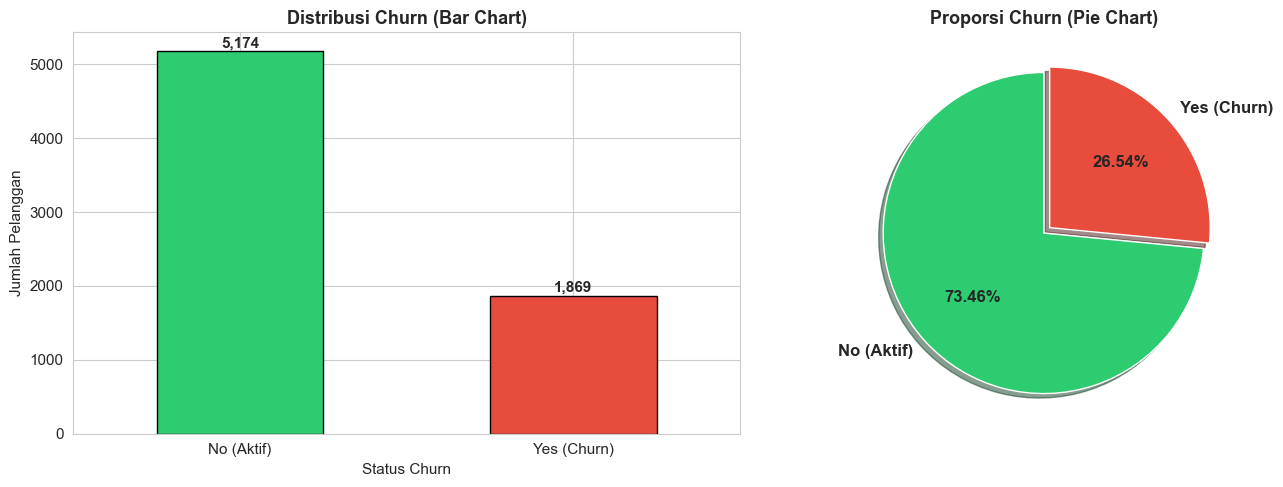


Insight:
- Sekitar 1 dari 4 pelanggan melakukan churn
- Dataset tergolong moderately imbalanced (rasio ~2.77:1)
- Saat modelling, gunakan metrik precision/recall/F1 selain accuracy


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Bar Chart ---
churn_counts.plot(
    kind='bar',
    ax=axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black'
)
axes[0].set_title('Distribusi Churn (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status Churn')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_xticklabels(['No (Aktif)', 'Yes (Churn)'], rotation=0)

# Tambah label nilai di atas tiap bar
for i, value in enumerate(churn_counts):
    axes[0].text(i, value + 50, f'{value:,}', ha='center', fontweight='bold')

# --- Subplot 2: Pie Chart ---
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(
    churn_counts,
    labels=['No (Aktif)', 'Yes (Churn)'],
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.05),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[1].set_title('Proporsi Churn (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nInsight:")
print("- Sekitar 1 dari 4 pelanggan melakukan churn")
print("- Dataset tergolong moderately imbalanced (rasio ~2.77:1)")
print("- Saat modelling, gunakan metrik precision/recall/F1 selain accuracy")

### 4.3 Analisis Fitur Numerik

Sebelum menganalisis distribusi numerik, kolom `TotalCharges` perlu dikonversi dulu dari tipe `object` menjadi `float` (sementara hanya untuk keperluan EDA). 11 baris dengan nilai kosong akan menjadi `NaN` dan diabaikan untuk visualisasi ini.

Fitur numerik yang dianalisis:
- **tenure** — lama berlangganan (bulan)
- **MonthlyCharges** — tagihan bulanan
- **TotalCharges** — total tagihan kumulatif
- **SeniorCitizen** — flag senior (0/1) — dianalisis sebagai biner

Analisis yang dilakukan:
1. Statistik deskriptif lengkap
2. Distribusi tiap fitur (histogram)
3. Distribusi fitur berdasarkan status Churn
4. Deteksi outlier (boxplot)
5. Korelasi antar fitur numerik (heatmap)

In [13]:
# Buat copy untuk EDA, dataset asli (df) tetap utuh
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

print("Tipe data TotalCharges setelah konversi:", df_eda['TotalCharges'].dtype)
print(f"NaN setelah konversi: {df_eda['TotalCharges'].isnull().sum()}")
print()

# Statistik deskriptif lengkap fitur numerik
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
print("Statistik deskriptif fitur numerik:")
print("=" * 60)
print(df_eda[numeric_features].describe().round(2))

Tipe data TotalCharges setelah konversi: float64
NaN setelah konversi: 11

Statistik deskriptif fitur numerik:
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7032.00
mean     32.37           64.76       2283.30
std      24.56           30.09       2266.77
min       0.00           18.25         18.80
25%       9.00           35.50        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.85       3794.74
max      72.00          118.75       8684.80


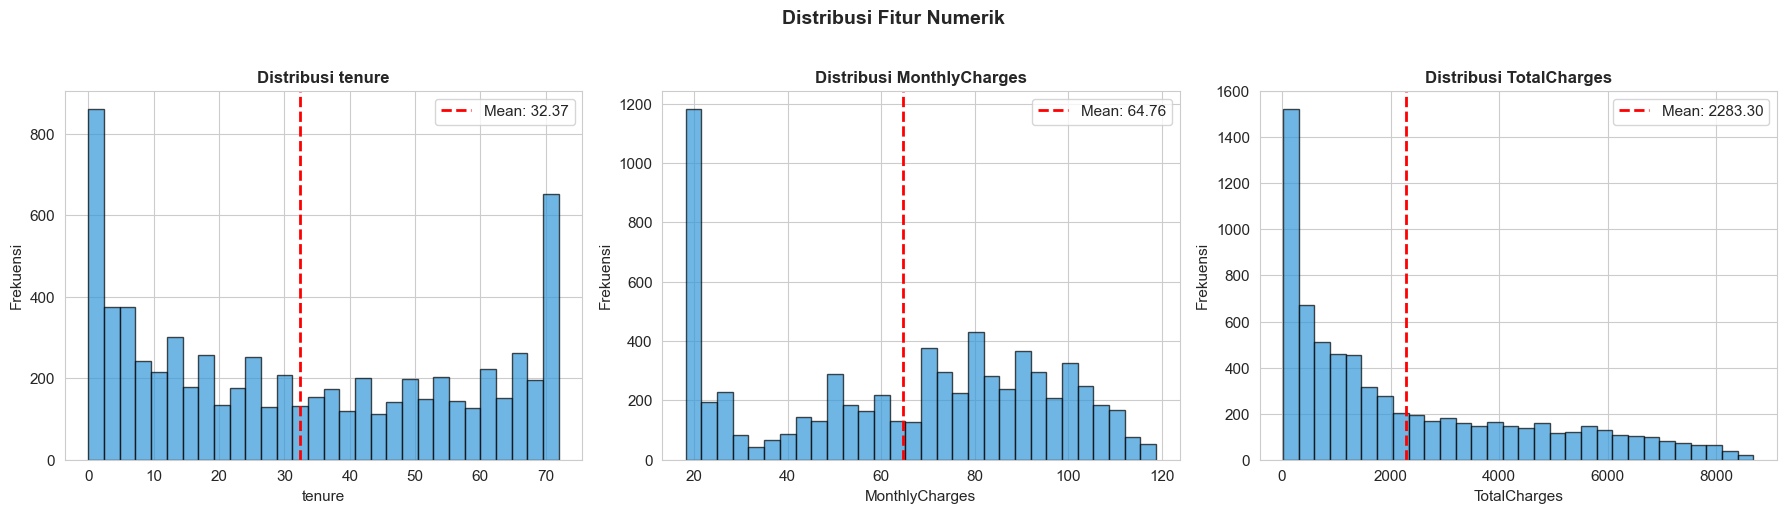

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numeric_features):
    axes[idx].hist(
        df_eda[col].dropna(),
        bins=30,
        color='#3498db',
        edgecolor='black',
        alpha=0.7
    )
    axes[idx].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frekuensi')
    
    # Tambah garis mean
    mean_val = df_eda[col].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].legend()

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

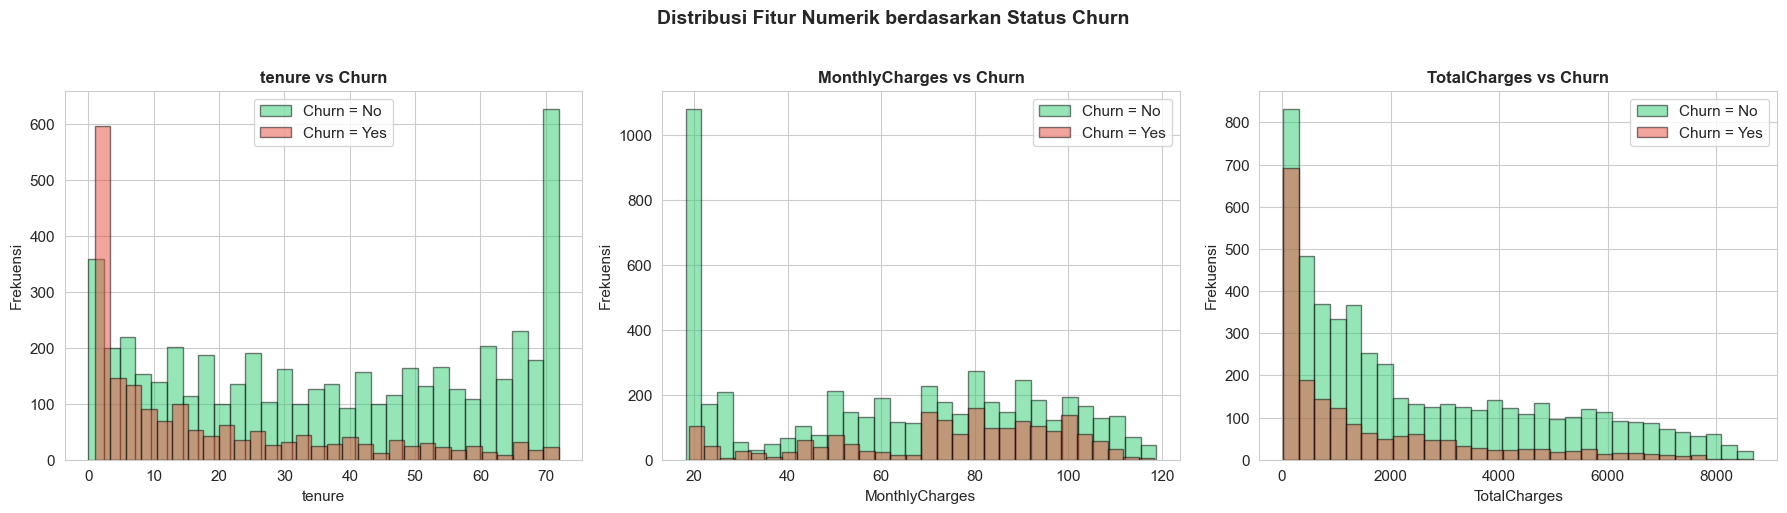

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numeric_features):
    for churn_status, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
        subset = df_eda[df_eda['Churn'] == churn_status][col].dropna()
        axes[idx].hist(
            subset,
            bins=30,
            color=color,
            edgecolor='black',
            alpha=0.5,
            label=f'Churn = {churn_status}'
        )
    
    axes[idx].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frekuensi')
    axes[idx].legend()

plt.suptitle('Distribusi Fitur Numerik berdasarkan Status Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

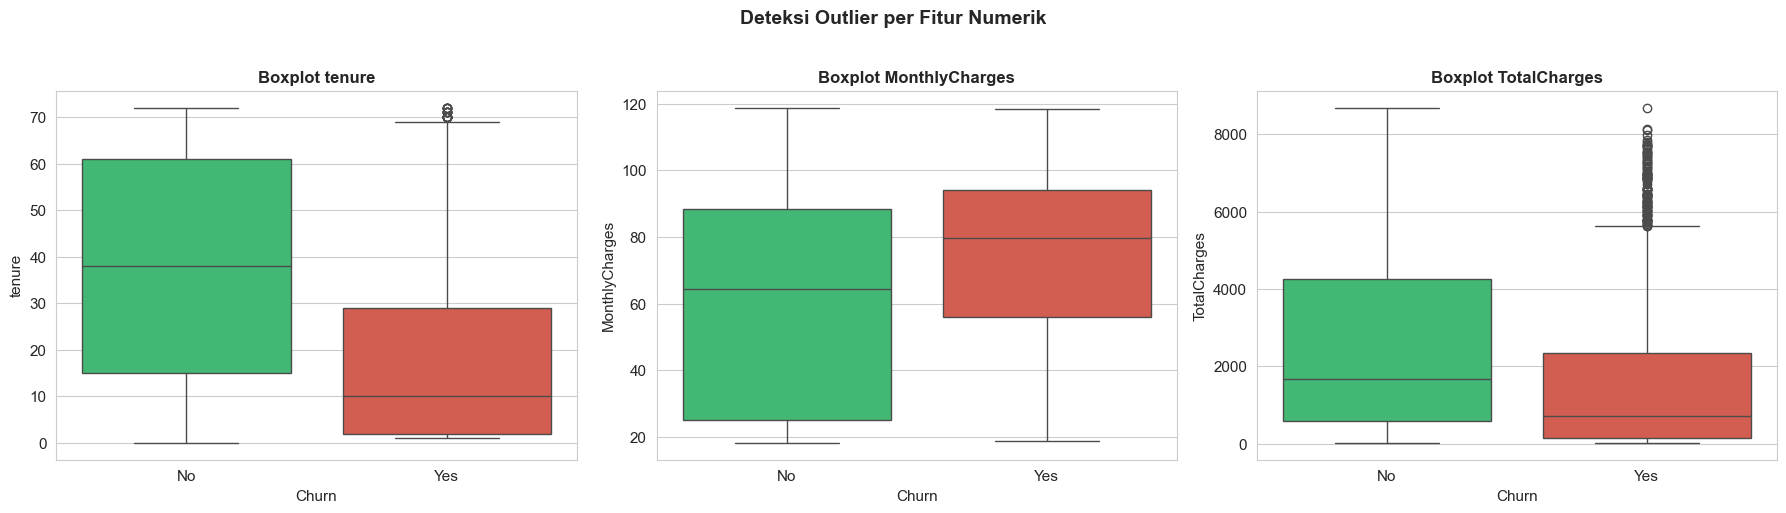

Deteksi Outlier (IQR Method):
tenure               | Outliers:    0 (0.00%)
MonthlyCharges       | Outliers:    0 (0.00%)
TotalCharges         | Outliers:    0 (0.00%)


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numeric_features):
    sns.boxplot(
        data=df_eda,
        y=col,
        x='Churn',
        ax=axes[idx],
        palette={'No': '#2ecc71', 'Yes': '#e74c3c'}
    )
    axes[idx].set_title(f'Boxplot {col}', fontsize=12, fontweight='bold')

plt.suptitle('Deteksi Outlier per Fitur Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Hitung outlier dengan IQR method
print("Deteksi Outlier (IQR Method):")
print("=" * 60)
for col in numeric_features:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_eda[(df_eda[col] < lower_bound) | (df_eda[col] > upper_bound)][col]
    print(f"{col:20s} | Outliers: {len(outliers):4d} ({len(outliers)/len(df_eda)*100:.2f}%)")

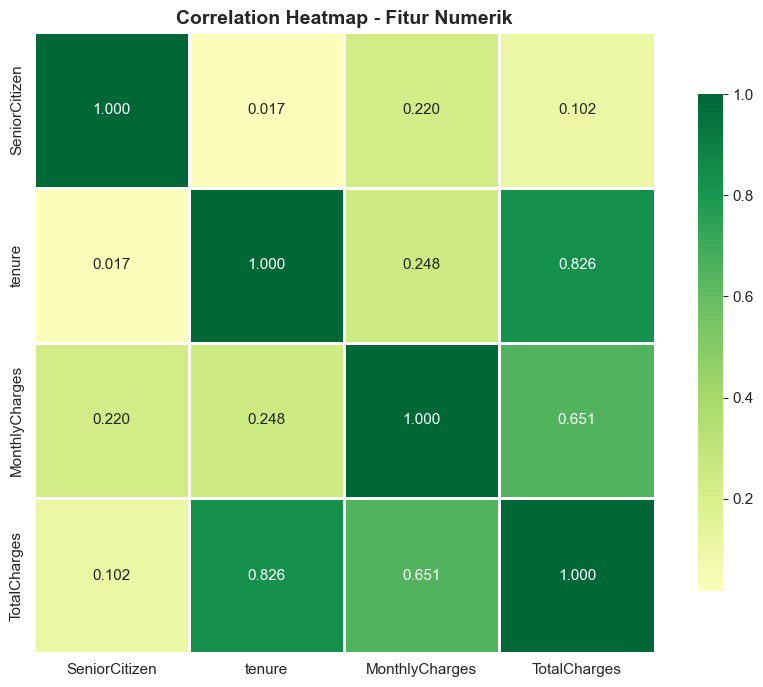


Insight Korelasi:
- tenure & TotalCharges: korelasi sangat tinggi (>0.8)
  -> wajar karena TotalCharges = MonthlyCharges x tenure
- MonthlyCharges & TotalCharges: korelasi sedang
- SeniorCitizen: korelasi lemah dengan semua fitur numerik


In [17]:
# Sertakan SeniorCitizen sebagai numerik (sudah biner 0/1)
corr_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df_eda[corr_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdYlGn',
    center=0,
    fmt='.3f',
    square=True,
    linewidths=1,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap - Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInsight Korelasi:")
print("- tenure & TotalCharges: korelasi sangat tinggi (>0.8)")
print("  -> wajar karena TotalCharges = MonthlyCharges x tenure")
print("- MonthlyCharges & TotalCharges: korelasi sedang")
print("- SeniorCitizen: korelasi lemah dengan semua fitur numerik")

### 4.4 Analisis Fitur Kategorikal

Mayoritas fitur dalam dataset Telco Churn bertipe kategorikal (16 dari 21 kolom). Analisis fitur kategorikal terhadap target `Churn` akan membantu mengidentifikasi:

1. **Distribusi setiap fitur** — apakah kategori-kategori terdistribusi merata atau ada yang dominan
2. **Hubungan dengan target** — fitur mana yang paling diskriminatif terhadap churn
3. **Kategori berisiko tinggi** — segmen pelanggan dengan churn rate tinggi

Pendekatan visualisasi yang digunakan: **stacked percentage bar chart** — menunjukkan proporsi churn untuk tiap kategori, sehingga mudah membandingkan tingkat churn antar kategori.

In [18]:
# Ambil fitur kategorikal kecuali customerID (identifier) dan Churn (target)
cat_features = [col for col in df_eda.select_dtypes(include=['object']).columns 
                if col not in ['customerID', 'Churn', 'TotalCharges']]

print(f"Total fitur kategorikal untuk analisis: {len(cat_features)}")
print()

# Tampilkan jumlah unique values per fitur
print("Jumlah kategori unik per fitur:")
print("=" * 50)
for col in cat_features:
    unique_vals = df_eda[col].nunique()
    print(f"{col:25s} | {unique_vals} kategori | {list(df_eda[col].unique())}")

Total fitur kategorikal untuk analisis: 15

Jumlah kategori unik per fitur:
gender                    | 2 kategori | ['Female', 'Male']
Partner                   | 2 kategori | ['Yes', 'No']
Dependents                | 2 kategori | ['No', 'Yes']
PhoneService              | 2 kategori | ['No', 'Yes']
MultipleLines             | 3 kategori | ['No phone service', 'No', 'Yes']
InternetService           | 3 kategori | ['DSL', 'Fiber optic', 'No']
OnlineSecurity            | 3 kategori | ['No', 'Yes', 'No internet service']
OnlineBackup              | 3 kategori | ['Yes', 'No', 'No internet service']
DeviceProtection          | 3 kategori | ['No', 'Yes', 'No internet service']
TechSupport               | 3 kategori | ['No', 'Yes', 'No internet service']
StreamingTV               | 3 kategori | ['No', 'Yes', 'No internet service']
StreamingMovies           | 3 kategori | ['No', 'Yes', 'No internet service']
Contract                  | 3 kategori | ['Month-to-month', 'One year', 'Two year']
Pa

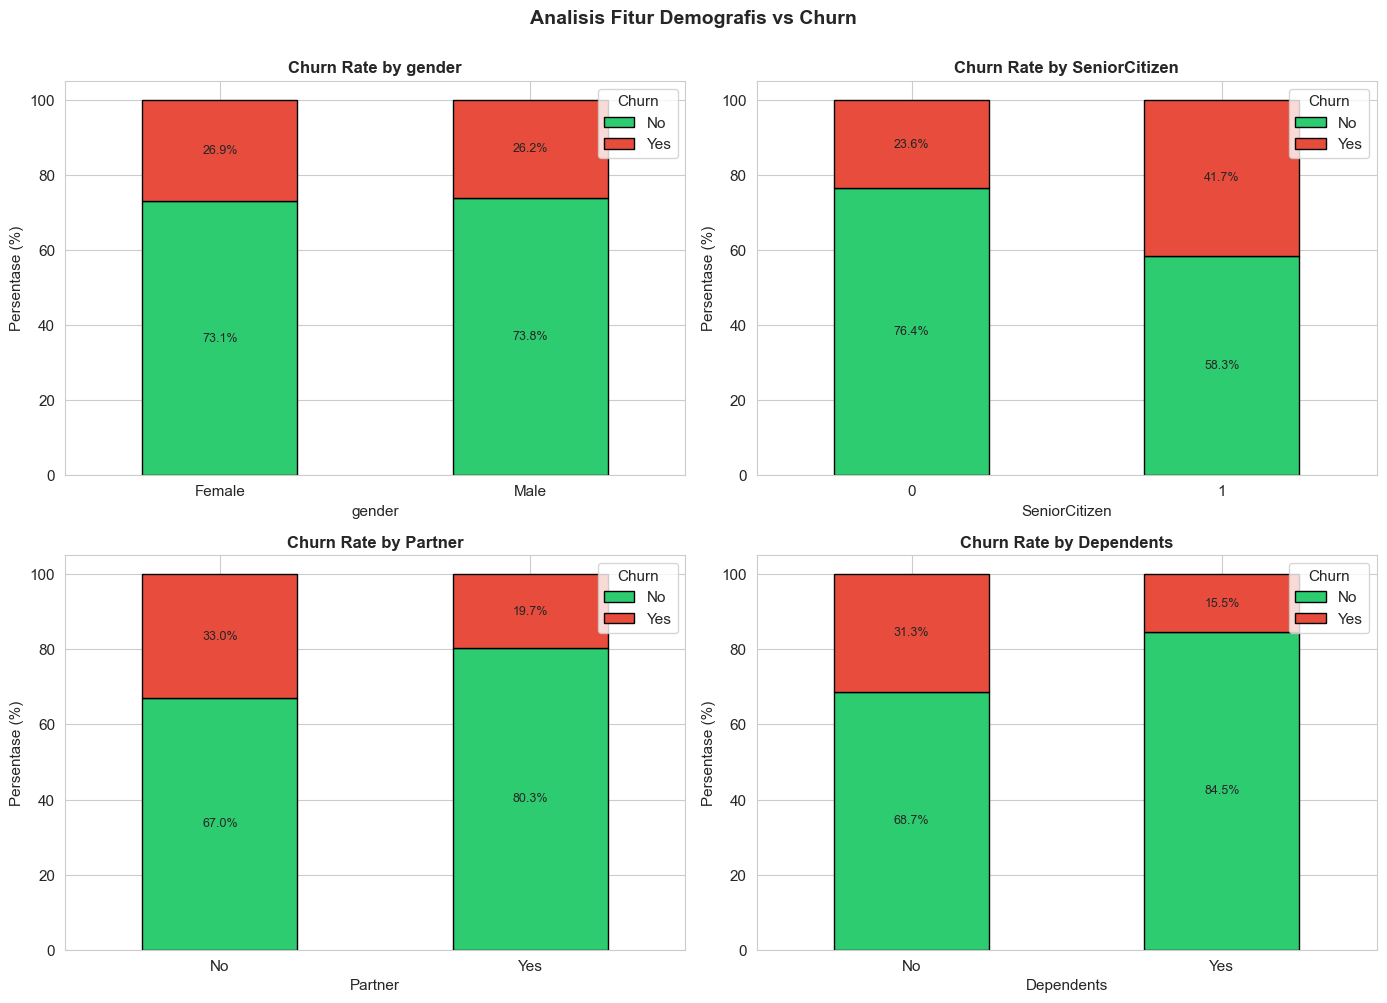

In [19]:
demographic_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(demographic_features):
    # Buat crosstab: distribusi Churn per kategori (dalam persen)
    crosstab = pd.crosstab(df_eda[col], df_eda['Churn'], normalize='index') * 100
    
    crosstab.plot(
        kind='bar',
        stacked=True,
        ax=axes[idx],
        color=['#2ecc71', '#e74c3c'],
        edgecolor='black'
    )
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Persentase (%)')
    axes[idx].set_xlabel(col)
    axes[idx].legend(title='Churn', loc='upper right')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)
    
    # Tambah label persentase di tiap segmen
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)

plt.suptitle('Analisis Fitur Demografis vs Churn', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

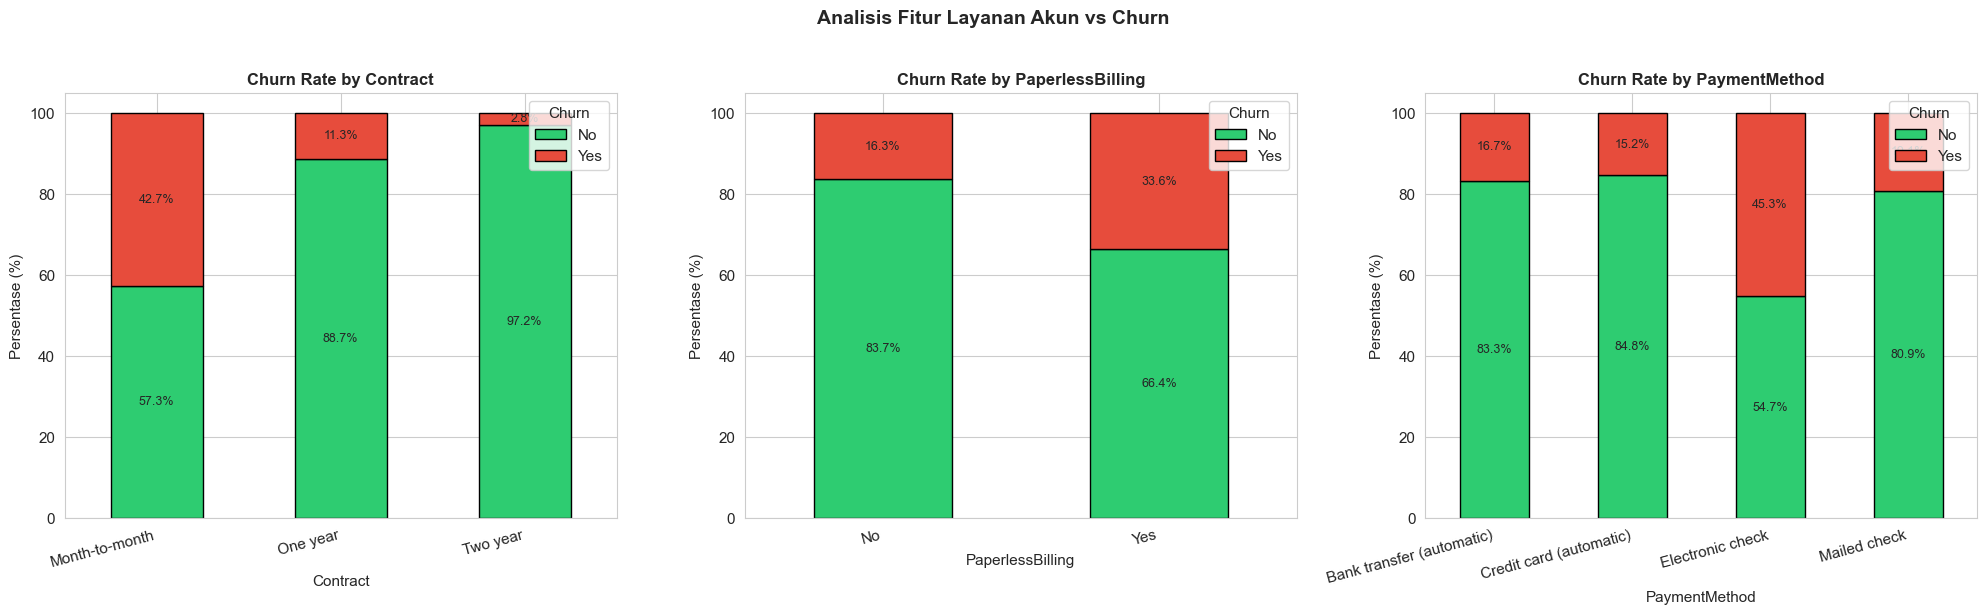

In [20]:
account_features = ['Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, col in enumerate(account_features):
    crosstab = pd.crosstab(df_eda[col], df_eda['Churn'], normalize='index') * 100
    
    crosstab.plot(
        kind='bar',
        stacked=True,
        ax=axes[idx],
        color=['#2ecc71', '#e74c3c'],
        edgecolor='black'
    )
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Persentase (%)')
    axes[idx].set_xlabel(col)
    axes[idx].legend(title='Churn', loc='upper right')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=15, ha='right')
    
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)

plt.suptitle('Analisis Fitur Layanan Akun vs Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

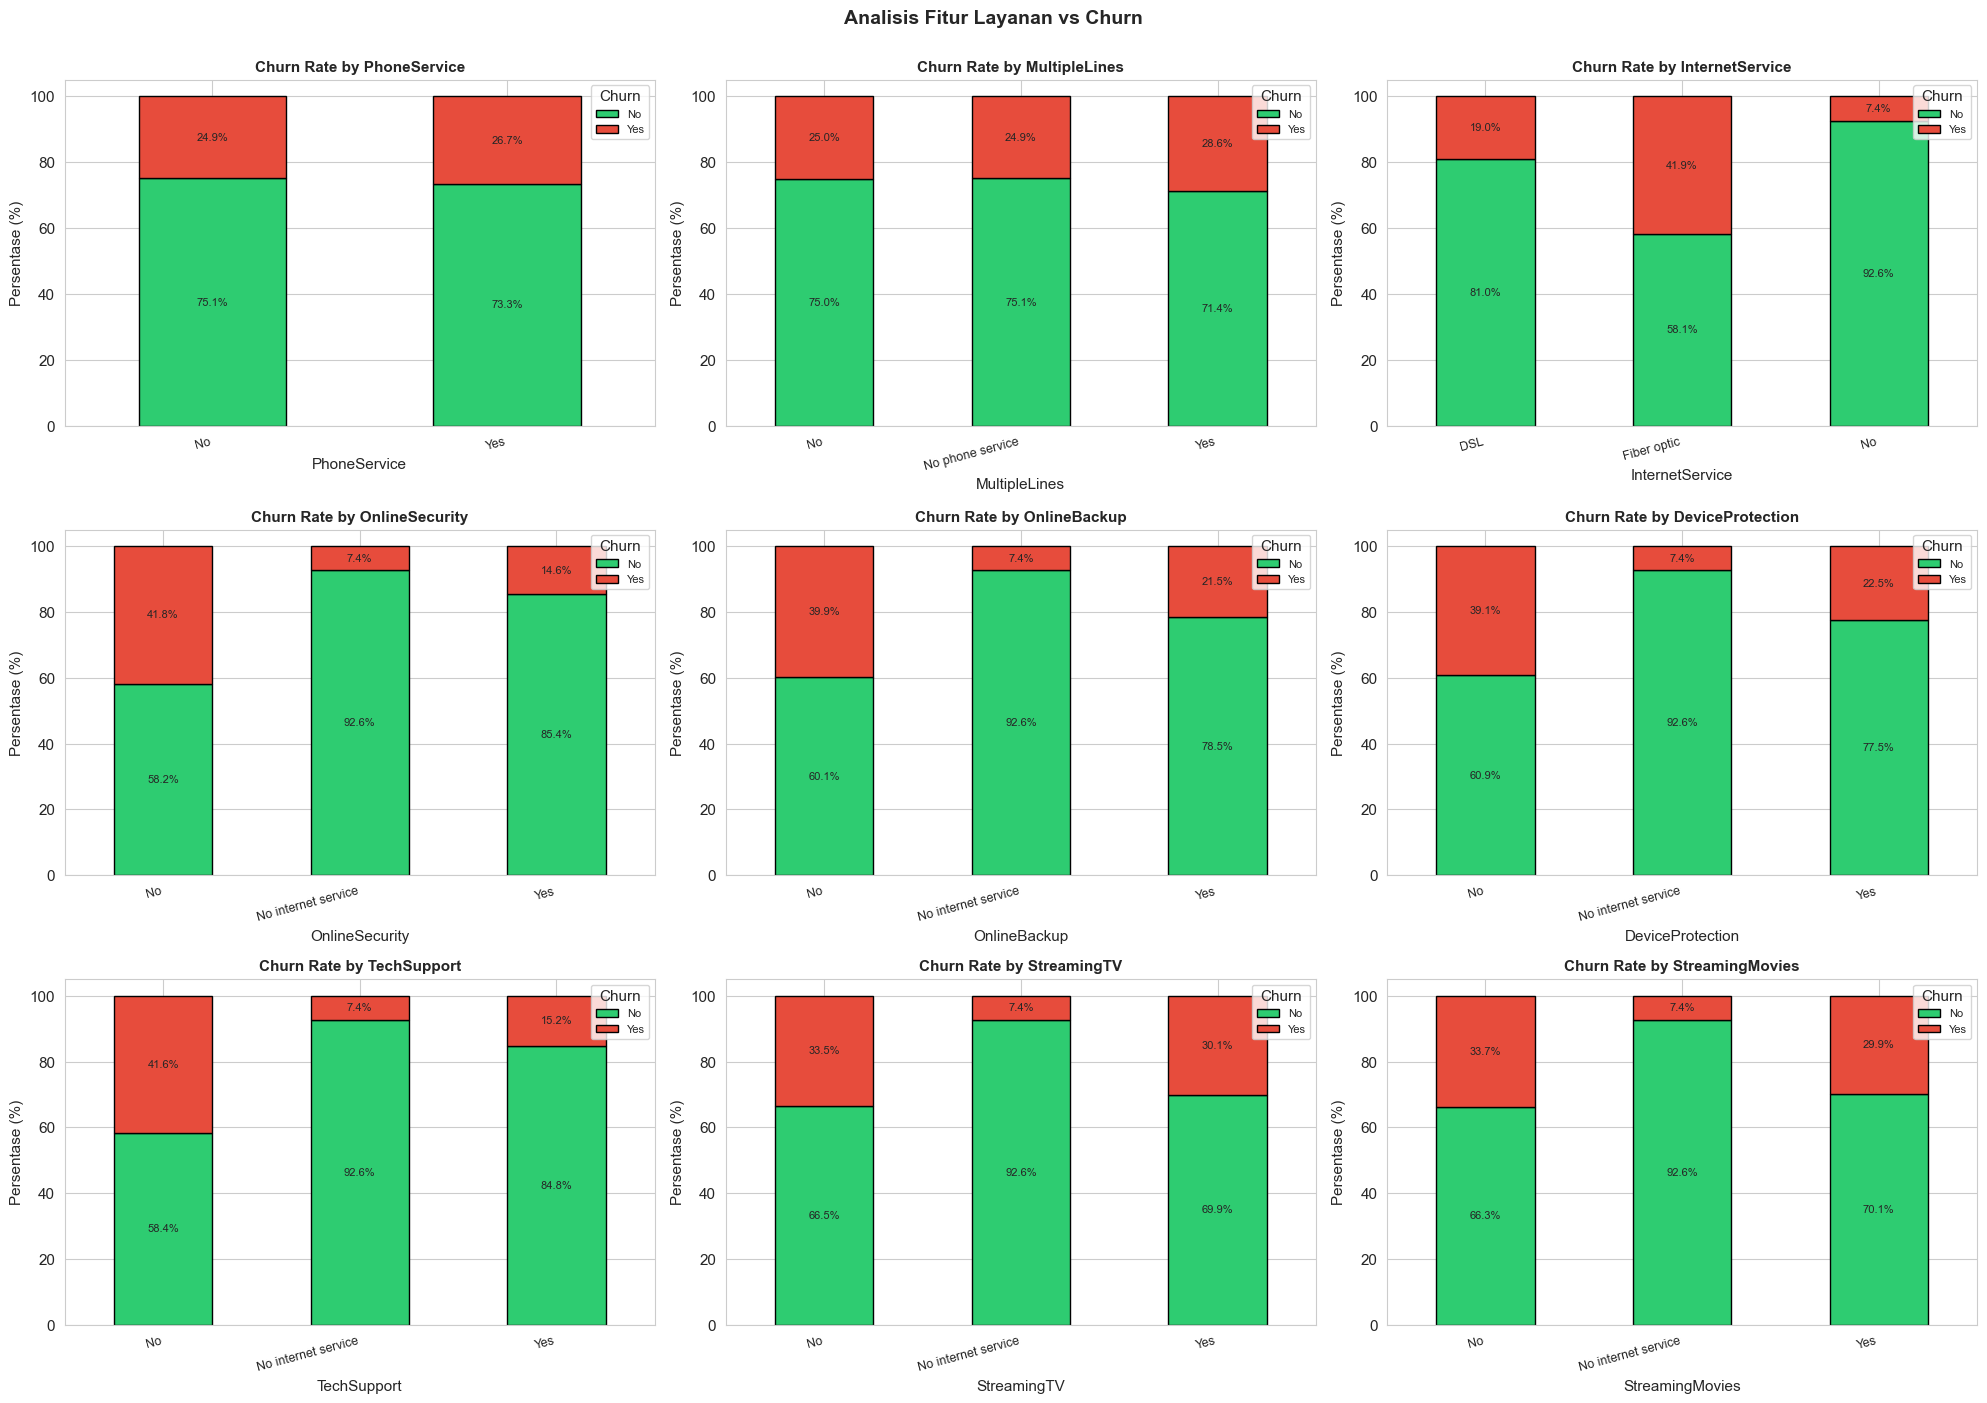

In [21]:
service_features = ['PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

for idx, col in enumerate(service_features):
    crosstab = pd.crosstab(df_eda[col], df_eda['Churn'], normalize='index') * 100
    
    crosstab.plot(
        kind='bar',
        stacked=True,
        ax=axes[idx],
        color=['#2ecc71', '#e74c3c'],
        edgecolor='black'
    )
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Persentase (%)')
    axes[idx].set_xlabel(col)
    axes[idx].legend(title='Churn', loc='upper right', fontsize=8)
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=15, ha='right', fontsize=9)
    
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

plt.suptitle('Analisis Fitur Layanan vs Churn', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [22]:
print("=" * 70)
print("RINGKASAN HASIL EDA - TELCO CUSTOMER CHURN")
print("=" * 70)

print("""
1. KUALITAS DATA
   - Dataset bersih dari duplikat dan missing NaN eksplisit
   - 11 baris TotalCharges berisi string kosong (hidden missing)
   - customerID 100% unik, akan di-drop saat preprocessing

2. TARGET VARIABLE
   - Churn rate: 26.54% (1.869 dari 7.043 pelanggan)
   - Dataset moderately imbalanced (rasio 2.77:1)
   - Implikasi: gunakan metrik F1/precision/recall, bukan hanya accuracy

3. FITUR NUMERIK
   - tenure: pelanggan baru (tenure rendah) lebih mungkin churn
   - MonthlyCharges: charges tinggi cenderung churn (>70)
   - TotalCharges: korelasi tinggi dengan tenure (0.83) - multikolinearitas
   - Outlier minimal di seluruh fitur numerik

4. FITUR KATEGORIKAL - PALING DISKRIMINATIF
   - Contract: Month-to-month churn 42% vs Two year hanya 3%
   - PaymentMethod: Electronic check punya churn 45%
   - InternetService: Fiber optic churn 42%
   - OnlineSecurity, TechSupport, OnlineBackup: tanpa fitur ini churn ~42%

5. FITUR KATEGORIKAL - LEMAH (kandidat drop)
   - gender: churn rate hampir sama untuk Male/Female
   - PhoneService: distribusi tidak diskriminatif

6. REKOMENDASI PREPROCESSING
   - Drop customerID (identifier)
   - Konversi TotalCharges ke numerik, isi 11 NaN dengan 0 (karena tenure=0)
   - Encoding kategorikal: Label Encoding untuk biner, One-Hot untuk multi-kategori
   - Scaling: StandardScaler untuk tenure, MonthlyCharges, TotalCharges
   - Konversi target Churn (Yes/No) -> (1/0)
""")

RINGKASAN HASIL EDA - TELCO CUSTOMER CHURN

1. KUALITAS DATA
   - Dataset bersih dari duplikat dan missing NaN eksplisit
   - 11 baris TotalCharges berisi string kosong (hidden missing)
   - customerID 100% unik, akan di-drop saat preprocessing

2. TARGET VARIABLE
   - Churn rate: 26.54% (1.869 dari 7.043 pelanggan)
   - Dataset moderately imbalanced (rasio 2.77:1)
   - Implikasi: gunakan metrik F1/precision/recall, bukan hanya accuracy

3. FITUR NUMERIK
   - tenure: pelanggan baru (tenure rendah) lebih mungkin churn
   - MonthlyCharges: charges tinggi cenderung churn (>70)
   - TotalCharges: korelasi tinggi dengan tenure (0.83) - multikolinearitas
   - Outlier minimal di seluruh fitur numerik

4. FITUR KATEGORIKAL - PALING DISKRIMINATIF
   - Contract: Month-to-month churn 42% vs Two year hanya 3%
   - PaymentMethod: Electronic check punya churn 45%
   - InternetService: Fiber optic churn 42%
   - OnlineSecurity, TechSupport, OnlineBackup: tanpa fitur ini churn ~42%

5. FITUR KATEGORIK

# **5. Data Preprocessing**

Berdasarkan hasil EDA, preprocessing dilakukan dengan tahapan berikut secara berurutan:

| # | Tahapan | Tujuan |
|---|---|---|
| 5.1 | Drop kolom identifier (`customerID`) | Hilangkan kolom yang tidak punya nilai prediktif |
| 5.2 | Handle `TotalCharges` | Konversi tipe object ke numerik & imputasi 11 missing dengan 0 |
| 5.3 | Konsolidasi nilai redundant | Ganti `"No internet/phone service"` menjadi `"No"` |
| 5.4 | Encoding fitur biner | Konversi Yes/No menjadi 1/0 untuk fitur biner |
| 5.5 | One-Hot Encoding | Konversi fitur multi-kategori menjadi dummy variables |
| 5.6 | Feature scaling | Standardisasi fitur numerik (`StandardScaler`) |
| 5.7 | Train-test split & save | Stratified split 80:20 dan simpan hasil ke CSV |

Output akhir disimpan dalam folder `telco_churn_preprocessing/`:
- `telco_churn_clean.csv` — full dataset preprocessed (untuk automation script Day 2)
- `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` — siap pakai untuk modelling

In [23]:
# Buat copy dari df asli untuk preprocessing (df_eda hanya untuk visualisasi)
df_clean = df.copy()

print("Working copy dibuat dari dataset asli")
print(f"Shape awal: {df_clean.shape}")
print(f"Kolom: {list(df_clean.columns)}")

Working copy dibuat dari dataset asli
Shape awal: (7043, 21)
Kolom: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [24]:
# customerID adalah identifier unik, tidak punya nilai prediktif
df_clean = df_clean.drop(columns=['customerID'])

print("Kolom 'customerID' berhasil di-drop")
print(f"Shape setelah drop: {df_clean.shape}")
print(f"Kolom tersisa: {df_clean.shape[1]}")

Kolom 'customerID' berhasil di-drop
Shape setelah drop: (7043, 20)
Kolom tersisa: 20


In [25]:
# Konversi ke numerik, baris dengan string kosong akan jadi NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Cek baris dengan TotalCharges NaN
nan_rows = df_clean[df_clean['TotalCharges'].isnull()]
print(f"Jumlah NaN di TotalCharges: {len(nan_rows)}")
print("\nKarakteristik baris NaN:")
print(nan_rows[['tenure', 'MonthlyCharges', 'TotalCharges']].head())
print(f"\nSemua memiliki tenure = 0? {(nan_rows['tenure'] == 0).all()}")

# Imputasi: karena tenure=0, total charges seharusnya 0 (pelanggan baru)
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# Verifikasi
print(f"\nNaN setelah imputasi: {df_clean['TotalCharges'].isnull().sum()}")
print(f"Tipe data TotalCharges: {df_clean['TotalCharges'].dtype}")

Jumlah NaN di TotalCharges: 11

Karakteristik baris NaN:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN

Semua memiliki tenure = 0? True

NaN setelah imputasi: 0
Tipe data TotalCharges: float64


In [26]:
# Fitur dengan nilai 'No internet service' atau 'No phone service'
# Nilai ini redundant dengan 'No' pada fitur InternetService/PhoneService
redundant_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                      'TechSupport', 'StreamingTV', 'StreamingMovies']
redundant_phone = ['MultipleLines']

print("Sebelum konsolidasi:")
for col in redundant_internet[:2]:  # tampilkan sample
    print(f"  {col}: {df_clean[col].unique()}")

# Replace 'No internet service' -> 'No'
for col in redundant_internet:
    df_clean[col] = df_clean[col].replace('No internet service', 'No')

# Replace 'No phone service' -> 'No'
for col in redundant_phone:
    df_clean[col] = df_clean[col].replace('No phone service', 'No')

print("\nSesudah konsolidasi:")
for col in redundant_internet[:2]:
    print(f"  {col}: {df_clean[col].unique()}")
for col in redundant_phone:
    print(f"  {col}: {df_clean[col].unique()}")

Sebelum konsolidasi:
  OnlineSecurity: ['No' 'Yes' 'No internet service']
  OnlineBackup: ['Yes' 'No' 'No internet service']

Sesudah konsolidasi:
  OnlineSecurity: ['No' 'Yes']
  OnlineBackup: ['Yes' 'No']
  MultipleLines: ['No' 'Yes']


In [27]:
# Fitur biner Yes/No -> 1/0
binary_features = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                   'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'PaperlessBilling']

for col in binary_features:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# Fitur biner gender: Male/Female -> 1/0
df_clean['gender'] = df_clean['gender'].map({'Male': 1, 'Female': 0})

# Target variable: Churn Yes/No -> 1/0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print("Fitur biner berhasil di-encode")
print(f"Total fitur biner di-encode: {len(binary_features) + 2}")  # +gender +Churn

# Verifikasi - sample 5 baris
print("\nSample data setelah encoding biner:")
print(df_clean[['gender', 'Partner', 'PhoneService', 'PaperlessBilling', 'Churn']].head())

Fitur biner berhasil di-encode
Total fitur biner di-encode: 13

Sample data setelah encoding biner:
   gender  Partner  PhoneService  PaperlessBilling  Churn
0       0        1             0                 1      0
1       1        0             1                 0      0
2       1        0             1                 1      1
3       1        0             0                 0      0
4       0        0             1                 1      1


In [28]:
# Fitur multi-kategori (> 2 nilai unik)
multi_cat_features = ['InternetService', 'Contract', 'PaymentMethod']

print("Sebelum One-Hot Encoding:")
for col in multi_cat_features:
    print(f"  {col}: {df_clean[col].unique()}")

# Apply One-Hot Encoding dengan drop_first=True untuk hindari multikolinearitas
df_clean = pd.get_dummies(df_clean, columns=multi_cat_features, drop_first=True, dtype=int)

print(f"\nShape setelah One-Hot Encoding: {df_clean.shape}")
print(f"\nKolom baru hasil One-Hot:")
new_cols = [col for col in df_clean.columns if any(prefix in col for prefix in multi_cat_features)]
for col in new_cols:
    print(f"  - {col}")

Sebelum One-Hot Encoding:
  InternetService: ['DSL' 'Fiber optic' 'No']
  Contract: ['Month-to-month' 'One year' 'Two year']
  PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Shape setelah One-Hot Encoding: (7043, 24)

Kolom baru hasil One-Hot:
  - InternetService_Fiber optic
  - InternetService_No
  - Contract_One year
  - Contract_Two year
  - PaymentMethod_Credit card (automatic)
  - PaymentMethod_Electronic check
  - PaymentMethod_Mailed check


In [29]:
# Fitur numerik yang perlu di-scale
numeric_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Statistik SEBELUM scaling:")
print(df_clean[numeric_to_scale].describe().round(2))

# Inisialisasi scaler
scaler = StandardScaler()

# Fit & transform
df_clean[numeric_to_scale] = scaler.fit_transform(df_clean[numeric_to_scale])

print("\nStatistik SESUDAH scaling:")
print(df_clean[numeric_to_scale].describe().round(4))

print("\nFitur numerik berhasil di-scale (mean=0, std=1)")

Statistik SEBELUM scaling:
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80

Statistik SESUDAH scaling:
          tenure  MonthlyCharges  TotalCharges
count  7043.0000       7043.0000     7043.0000
mean     -0.0000         -0.0000       -0.0000
std       1.0001          1.0001        1.0001
min      -1.3182         -1.5459       -1.0058
25%      -0.9517         -0.9725       -0.8299
50%      -0.1373          0.1857       -0.3905
75%       0.9215          0.8338        0.6648
max       1.6137          1.7944        2.8258

Fitur numerik berhasil di-scale (mean=0, std=1)


In [30]:
# Pisahkan fitur (X) dan target (y)
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

print(f"Shape fitur (X): {X.shape}")
print(f"Shape target (y): {y.shape}")

# Stratified split untuk pertahankan rasio Churn di train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"\nTrain shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test shape : X={X_test.shape}, y={y_test.shape}")

# Verifikasi distribusi Churn pertahankan rasio
print(f"\nChurn rate train: {y_train.mean()*100:.2f}%")
print(f"Churn rate test : {y_test.mean()*100:.2f}%")

# ============================================
# SAVE HASIL PREPROCESSING
# ============================================

# Buat folder output (relatif ke notebook di preprocessing/)
output_dir = "../telco_churn_preprocessing"
os.makedirs(output_dir, exist_ok=True)

# Save dataset full preprocessed (untuk automate.py Day 2)
clean_path = os.path.join(output_dir, "telco_churn_clean.csv")
df_clean.to_csv(clean_path, index=False)

# Save split data (untuk modelling Day 3)
X_train.to_csv(os.path.join(output_dir, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(output_dir, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(output_dir, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(output_dir, "y_test.csv"), index=False)

print(f"\nSemua file berhasil disimpan di: {output_dir}/")
print(f"  - telco_churn_clean.csv ({df_clean.shape[0]:,} baris x {df_clean.shape[1]} kolom)")
print(f"  - X_train.csv ({X_train.shape[0]:,} baris)")
print(f"  - X_test.csv ({X_test.shape[0]:,} baris)")
print(f"  - y_train.csv ({y_train.shape[0]:,} baris)")
print(f"  - y_test.csv ({y_test.shape[0]:,} baris)")

Shape fitur (X): (7043, 23)
Shape target (y): (7043,)

Train shape: X=(5634, 23), y=(5634,)
Test shape : X=(1409, 23), y=(1409,)

Churn rate train: 26.54%
Churn rate test : 26.54%

Semua file berhasil disimpan di: ../telco_churn_preprocessing/
  - telco_churn_clean.csv (7,043 baris x 24 kolom)
  - X_train.csv (5,634 baris)
  - X_test.csv (1,409 baris)
  - y_train.csv (5,634 baris)
  - y_test.csv (1,409 baris)


In [31]:
print("=" * 70)
print("VERIFIKASI FINAL - DATASET PREPROCESSED")
print("=" * 70)

print(f"\n1. Dimensi final: {df_clean.shape}")
print(f"2. Total fitur (excluding target): {df_clean.shape[1] - 1}")
print(f"3. Missing values: {df_clean.isnull().sum().sum()}")
print(f"4. Tipe data:")
print(df_clean.dtypes.value_counts())

print(f"\n5. Sample 3 baris data preprocessed:")
print(df_clean.head(3))

print(f"\n6. Distribusi target Churn:")
print(df_clean['Churn'].value_counts())

print("\n" + "=" * 70)
print("PREPROCESSING SELESAI - DATA SIAP UNTUK MODELLING")
print("=" * 70)

VERIFIKASI FINAL - DATASET PREPROCESSED

1. Dimensi final: (7043, 24)
2. Total fitur (excluding target): 23
3. Missing values: 0
4. Tipe data:
int64      21
float64     3
Name: count, dtype: int64

5. Sample 3 baris data preprocessed:
   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0       0              0        1           0 -1.277445             0   
1       1              0        0           0  0.066327             1   
2       1              0        0           0 -1.236724             1   

   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0              0               0             1                 0            0   
1              0               1             0                 1            0   
2              0               1             1                 0            0   

   StreamingTV  StreamingMovies  PaperlessBilling  MonthlyCharges  \
0            0                0                 1       -1.160323   
1        